In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load CSV  for benin-malanville
df = pd.read_csv("../data/sierraleone-bumbuna.csv")
print("Shape:", df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
# Only fill NaN for numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# If you want to drop columns that are all NaN, like 'Comments':
df = df.drop(columns=['Comments'])


Shape: (525600, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB    

In [5]:
# 5️⃣ Detect outliers
df['z_GHI'] = zscore(df['GHI'])
df = df[df['z_GHI'].abs() < 3]
print(df)
df.drop(columns=['z_GHI'], inplace=True)

               Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb     RH   WS  WSgust  \
0       2021-10-30 00:01 -0.7 -0.1 -0.8   0.0   0.0  21.9   99.1  0.0     0.0   
1       2021-10-30 00:02 -0.7 -0.1 -0.8   0.0   0.0  21.9   99.2  0.0     0.0   
2       2021-10-30 00:03 -0.7 -0.1 -0.8   0.0   0.0  21.9   99.2  0.0     0.0   
3       2021-10-30 00:04 -0.7  0.0 -0.8   0.0   0.0  21.9   99.3  0.0     0.0   
4       2021-10-30 00:05 -0.7 -0.1 -0.8   0.0   0.0  21.9   99.3  0.0     0.0   
...                  ...  ...  ...  ...   ...   ...   ...    ...  ...     ...   
525595  2022-10-29 23:56 -1.6 -0.1 -2.9   0.0   0.0  24.0  100.0  0.0     0.0   
525596  2022-10-29 23:57 -1.7 -0.1 -3.0   0.0   0.0  24.0  100.0  0.0     0.0   
525597  2022-10-29 23:58 -1.7 -0.1 -3.1   0.0   0.0  24.0  100.0  0.0     0.0   
525598  2022-10-29 23:59 -1.7 -0.2 -3.3   0.0   0.0  23.9  100.0  0.0     0.0   
525599  2022-10-30 00:00 -1.7 -0.1 -3.4   0.0   0.0  23.9  100.0  0.0     0.0   

        WSstdev   WD  WDstd

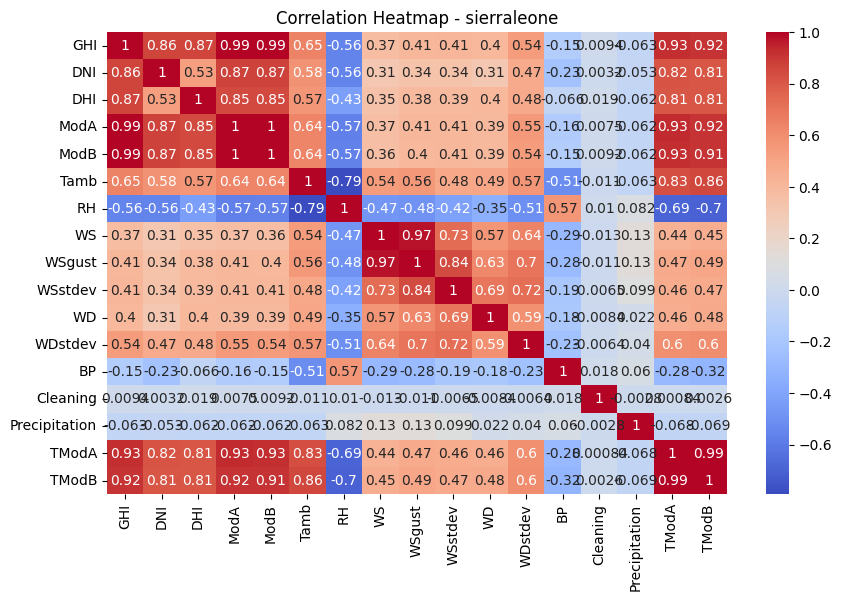

                    GHI       DNI       DHI      ModA      ModB      Tamb  \
GHI            1.000000  0.863764  0.865960  0.994975  0.994558  0.647258   
DNI            0.863764  1.000000  0.527221  0.871691  0.870145  0.581110   
DHI            0.865960  0.527221  1.000000  0.849235  0.850013  0.568810   
ModA           0.994975  0.871691  0.849235  1.000000  0.999139  0.641955   
ModB           0.994558  0.870145  0.850013  0.999139  1.000000  0.638760   
Tamb           0.647258  0.581110  0.568810  0.641955  0.638760  1.000000   
RH            -0.557262 -0.557294 -0.434582 -0.574351 -0.567660 -0.792177   
WS             0.371736  0.309794  0.345761  0.366308  0.364705  0.539138   
WSgust         0.411698  0.339962  0.384214  0.406345  0.404704  0.556804   
WSstdev        0.412563  0.336312  0.388529  0.409280  0.408021  0.483274   
WD             0.403895  0.312705  0.401996  0.393166  0.393061  0.490404   
WDstdev        0.544753  0.471173  0.479938  0.546274  0.544261  0.572082   

In [7]:
# Select only numeric columns for the correlation heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - sierraleone')
plt.show()
# Get and print the full correlation matrix for all numeric columns
corr_matrix = numeric_cols.corr()
print(corr_matrix)


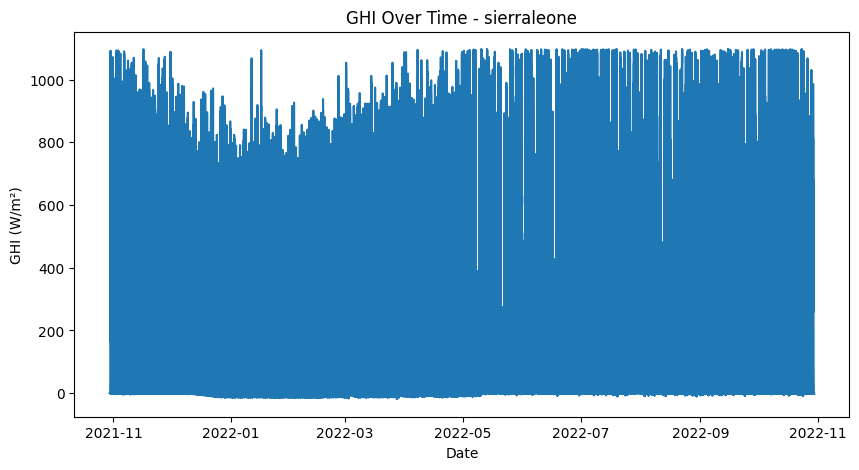

In [10]:
# 8️⃣ Plot GHI over time
plt.figure(figsize=(10,5))
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
plt.plot(df['Timestamp'], df['GHI'])
plt.title('GHI Over Time - sierraleone')
plt.xlabel('Date')
plt.ylabel('GHI (W/m²)')
plt.show()


In [12]:
df.to_csv('../data/sierraleone-bumbuna.csv', index=False)

In [13]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("../data/sierraleone-bumbuna.csv")

# --- STEP 1: Basic checks ---
print("Shape before cleaning:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

# --- STEP 2: Handle missing values ---
missing = df.isna().sum()
print("\nMissing values before cleaning:\n", missing[missing > 0])

# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# --- STEP 3: Outlier removal for GHI (if exists) ---
if "GHI" in df.columns:
    df['z_GHI'] = zscore(df['GHI'])
    df = df[df['z_GHI'].abs() < 3]
    df.drop(columns=['z_GHI'], inplace=True)
else:
    print("⚠️ Warning: Column 'GHI' not found — skipping outlier cleaning.")

# --- STEP 4: Save cleaned file ---
output_path = "../data/sierraleone_clean.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Cleaned data saved successfully as {output_path}")
print("Shape after cleaning:", df.shape)


Shape before cleaning: (523123, 18)
Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']
             Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-30 00:01:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.1  0.0     0.0   
1  2021-10-30 00:02:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   
2  2021-10-30 00:03:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   

   WSstdev   WD  WDstdev    BP  Cleaning  Precipitation  TModA  TModB  
0      0.0  0.0      0.0  1002         0            0.0   22.3   22.6  
1      0.0  0.0      0.0  1002         0            0.0   22.3   22.6  
2      0.0  0.0      0.0  1002         0            0.0   22.3   22.6  

Missing values before cleaning:
 Series([], dtype: int64)

✅ Cleaned data saved successfully as ../data/sierraleone_clean.csv
Shape after cleaning: (522309, 18)
